## Forecasting Modeling

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
from pathlib import Path
import lightgbm as lgb
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [2]:
# Set constant variables
SEED   = 42
DIR    = Path('/kaggle/input/competitions/datathon-2026-round-1/')
np.random.seed(SEED)

# Set timestamp
TRAIN_END   = pd.Timestamp('2022-12-31')
TEST_START  = pd.Timestamp('2023-01-01')
TEST_END    = pd.Timestamp('2024-07-01')

# Validation mirrors test: last 18 months of training
VAL_START   = pd.Timestamp('2021-07-01')
VAL_END     = TRAIN_END

In [3]:
# Load dataset
df_sales = pd.read_csv(DIR / 'sales.csv', parse_dates=['Date']).sort_values('Date').reset_index(drop=True)
df_promotions = pd.read_csv(DIR / 'promotions.csv', parse_dates=['start_date', 'end_date'])
df_web_traffic = pd.read_csv(DIR / 'web_traffic.csv', parse_dates=['date']).rename(columns={'date': 'Date'})
df_sample_submission = pd.read_csv(DIR / 'sample_submission.csv', parse_dates=['Date'])
df_order_items = pd.read_csv(DIR / 'order_items.csv', low_memory=False)
df_inventory = pd.read_csv(DIR / 'inventory.csv')

print(f"  Sales: {df_sales['Date'].min().date()} → {df_sales['Date'].max().date()} ({len(df_sales)} days)")
print(f"  Test : {TEST_START.date()} → {TEST_END.date()} ({len(df_sample_submission)} days)")
print(f"  Val  : {VAL_START.date()} → {VAL_END.date()} (mirrors test horizon)")

  Sales: 2012-07-04 → 2022-12-31 (3833 days)
  Test : 2023-01-01 → 2024-07-01 (548 days)
  Val  : 2021-07-01 → 2022-12-31 (mirrors test horizon)


In [4]:
# Build master daily dataframe
full_range = pd.date_range(df_sales['Date'].min(), TEST_END, freq='D')
df = pd.DataFrame({'Date': full_range})
df = df.merge(df_sales[['Date', 'Revenue', 'COGS']], on='Date', how='left')

# Promo calendar
df['has_promo'] = 0
for _, p in df_promotions.iterrows():
    m = (df['Date'] >= p['start_date']) & (df['Date'] <= p['end_date'])
    df.loc[m, 'has_promo'] = 1

# LEFT JOIN web traffic + ffill for test period
# df = df.merge(df_web_traffic[['Date', 'sessions']], on='Date', how='left')
# df['sessions'] = df['sessions'].ffill().bfill()

df_master = df.copy().sort_values('Date').reset_index(drop=True)
print(f"Master frame: {len(df_master)} rows | NaN Revenue: {df_master['Revenue'].isna().sum()}")
display(df_master)

Master frame: 4381 rows | NaN Revenue: 548


,Date,Revenue,COGS,has_promo
0,2012-07-04,5123547.94,3982991.19,0
1,2012-07-05,2751773.45,2150580.23,0
2,2012-07-06,3054029.42,2517632.84,0
3,2012-07-07,2667930.94,2108246.62,0
4,2012-07-08,2360851.90,1808622.79,0
...,...,...,...,...
4376,2024-06-27,NaN,NaN,0
4377,2024-06-28,NaN,NaN,0
4378,2024-06-29,NaN,NaN,0
4379,2024-06-30,NaN,NaN,0


In [5]:
SPIKE_PERCENTILE = 95
spike_thresh = np.percentile(df_master['Revenue'], SPIKE_PERCENTILE)
spike_mask   = df_master['Revenue'] > spike_thresh
n_spikes     = spike_mask.sum()

print(f"  Spike threshold (p{SPIKE_PERCENTILE}): {spike_thresh:,.0f}")
print(f"  Spike days in train: {n_spikes} ({n_spikes/len(df_master)*100:.1f}%)")
print(f"  Avg Revenue (spike days): {df_master.loc[spike_mask, 'Revenue'].mean():,.0f}")
print(f"  Avg Revenue (normal days): {df_master.loc[~spike_mask, 'Revenue'].mean():,.0f}")

  Spike threshold (p95): nan
  Spike days in train: 0 (0.0%)
  Avg Revenue (spike days): nan
  Avg Revenue (normal days): 4,286,584


In [6]:
def build_features(df):
    df = df.copy()
    d  = df['Date']

    # ── Temporal
    df['month']   = d.dt.month
    df['dom']     = d.dt.day
    df['dow']     = d.dt.dayofweek
    df['doy']     = d.dt.dayofyear
    df['year']    = d.dt.year
    df['quarter'] = d.dt.quarter
    df['is_weekend']    = (df['dow'] >= 5).astype(int)
    df['is_month_end']  = (df['dom'] >= 27).astype(int)
    df['is_month_start']= (df['dom'] <= 3).astype(int)
    df['is_qtr_end']    = ((df['month'].isin([3,6,9,12])) & (df['dom'] >= 25)).astype(int)

    # Payday proximity
    dist_to_25   = np.where(df['dom'] <= 25, 25 - df['dom'], 999)
    dist_to_1    = d.dt.daysinmonth - df['dom'] + 1
    df['dist_to_payday'] = np.minimum(dist_to_25, dist_to_1)

    # ── Fourier (4 harmonics annual + 1 weekly)
    for k in [1, 2, 3, 4]:
        df[f'sin_{k}'] = np.sin(2 * np.pi * k * df['doy'] / 365.25)
        df[f'cos_{k}'] = np.cos(2 * np.pi * k * df['doy'] / 365.25)
    df['sin_w'] = np.sin(2 * np.pi * df['dow'] / 7)
    df['cos_w'] = np.cos(2 * np.pi * df['dow'] / 7)

    # ── Vietnamese events
    df['is_double_day'] = ((df['month'] == df['dom']) & (df['month'] >= 9)).astype(int)
    df['is_holiday'] = (
        ((df['dom'] == 30) & (df['month'] == 4)) | ((df['dom'] == 1) & (df['month'] == 5)) |
        ((df['dom'] == 2)  & (df['month'] == 9)) | ((df['dom'] == 1) & (df['month'] == 1)) |
        ((df['dom'] == 24) & (df['month'] == 12))
    ).astype(int)

    # Lunar New Year proximity
    tet_dates = pd.to_datetime([
        '2012-01-23','2013-02-10','2014-01-31','2015-02-19','2016-02-08',
        '2017-01-28','2018-02-16','2019-02-05','2020-01-25','2021-02-12',
        '2022-02-01','2023-01-22','2024-02-10'
    ])
    df['dist_to_tet'] = 9999
    for t in tet_dates:
        diff = (t - df['Date']).dt.days
        df['dist_to_tet'] = np.where(diff.abs() < df['dist_to_tet'].abs(), diff, df['dist_to_tet'])
    df['pre_tet_30'] = df['dist_to_tet'].between(1, 30).astype(int)
    df['is_tet']     = df['dist_to_tet'].between(-4, 2).astype(int)
    df.drop(columns=['dist_to_tet'], inplace=True)

    # ── Promo features (historical probability lookup — no look-ahead)
    train_mask = df['year'] < 2023

    promo_by_md  = (df[train_mask].groupby(['month','dom'])['has_promo']
                    .mean().reset_index().rename(columns={'has_promo':'prob_md'}))
    promo_by_dow = (df[train_mask].groupby(['dow'])['has_promo']
                    .mean().reset_index().rename(columns={'has_promo':'prob_dow'}))
    
    df = df.merge(promo_by_md, on=['month','dom'], how='left')
    df = df.merge(promo_by_dow, on=['dow'], how='left')
    df['promo_intensity'] = (df['prob_md'].fillna(0) + df['prob_dow'].fillna(0)) / 2
    df.drop(columns=['prob_md', 'prob_dow', 'has_promo'], inplace=True, errors='ignore')

    # ── SAFE LAG FEATURES — all >= 364 days, references only actual training data
    # No recursive prediction needed for the 548-day test horizon
    rev = df['Revenue']
    for lag in [364, 728]:
        df[f'lag_{lag}'] = rev.shift(lag)

    # Rolling windows anchored
    df['roll7_ly']  = df['lag_364'].rolling(7,  min_periods=1).mean()
    df['roll28_ly'] = df['lag_364'].rolling(28, min_periods=1).mean()
    #df['roll90_ly'] = df['lag_364'].rolling(90, min_periods=1).mean()
    
    df['roll7_2y']  = df['lag_728'].rolling(7,  min_periods=1).mean()
    df['roll28_2y'] = df['lag_728'].rolling(28, min_periods=1).mean()

    # YoY Momentum
    df['yoy_ratio']    = df['lag_364'] / (df['lag_728'] + 1e-9)
    df['roll28_ratio'] = df['roll28_ly'] / (df['roll28_2y'] + 1e-9)

    # Web Traffic
    if 'sessions' in df.columns:
        df['log_sessions'] = np.log1p(df['sessions'].fillna(0))
        df['sessions_lag_364'] = df['sessions'].shift(364)
        df['roll7_sessions_ly'] = df['sessions_lag_364'].rolling(7, min_periods=1).mean()
        
        df['cr_lag_364'] = df['lag_364'] / (df['sessions_lag_364'] + 1e-9)
        df['roll7_cr_ly'] = df['cr_lag_364'].rolling(7, min_periods=1).mean()
        df.drop(columns=['cr_lag_364', 'sessions'], inplace=True, errors='ignore')

    return df

print("Building features...")
df = build_features(df_master)

EXCLUDE   = {'Date', 'Revenue', 'COGS', 'has_promo', 'sessions', 'year'}
FEAT_COLS = list(dict.fromkeys(
    [c for c in df.columns if c not in EXCLUDE and df[c].dtype in [float, np.float64, int, np.int64, np.int32]]
))

print(f"Feature columns  : {len(FEAT_COLS)}")
print(f"NaN in test features: {df.loc[df['Date'].between(TEST_START,TEST_END), FEAT_COLS].isna().sum().sum()}")
df.to_csv('df_features.csv', index=False)
display(df)

Building features...
Feature columns  : 33
NaN in test features: 860


,Date,Revenue,COGS,month,dom,dow,doy,year,quarter,is_weekend,...,is_tet,promo_intensity,lag_364,lag_728,roll7_ly,roll28_ly,roll7_2y,roll28_2y,yoy_ratio,roll28_ratio
0,2012-07-04,5123547.94,3982991.19,7,4,2,186,2012,3,0,...,0,0.678998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2012-07-05,2751773.45,2150580.23,7,5,3,187,2012,3,0,...,0,0.678086,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2012-07-06,3054029.42,2517632.84,7,6,4,188,2012,3,0,...,0,0.678998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2012-07-07,2667930.94,2108246.62,7,7,5,189,2012,3,1,...,0,0.676261,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2012-07-08,2360851.90,1808622.79,7,8,6,190,2012,3,1,...,0,0.675752,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4376,2024-06-27,NaN,NaN,6,27,3,179,2024,2,0,...,0,0.723540,NaN,5503799.91,NaN,NaN,4.764152e+06,4.254058e+06,NaN,NaN
4377,2024-06-28,NaN,NaN,6,28,4,180,2024,2,0,...,0,0.724453,NaN,5150082.22,NaN,NaN,4.880694e+06,4.202792e+06,NaN,NaN
4378,2024-06-29,NaN,NaN,6,29,5,181,2024,2,1,...,0,0.721715,NaN,4591824.74,NaN,NaN,5.015130e+06,4.259681e+06,NaN,NaN
4379,2024-06-30,NaN,NaN,6,30,6,182,2024,2,1,...,0,0.721207,NaN,3487232.00,NaN,NaN,5.039891e+06,4.279028e+06,NaN,NaN


In [7]:
# ── Training masks
lag_warmup  = df['Date'].min() + pd.Timedelta(days=728)
train_mask  = (df['Date'] >= lag_warmup) & (df['Date'] <= TRAIN_END) & df['Revenue'].notna()
val_mask    = (df['Date'] >= VAL_START)  & (df['Date'] <= TRAIN_END)
pre_val     = train_mask & (df['Date'] < VAL_START)
test_mask   = df['Date'].between(TEST_START, TEST_END)

X_tr = df.loc[pre_val,   FEAT_COLS];  y_tr = df.loc[pre_val,   'Revenue']
X_va = df.loc[val_mask,  FEAT_COLS];  y_va = df.loc[val_mask,  'Revenue']
X_te = df.loc[test_mask, FEAT_COLS]

print(f"Train (pre-val): {pre_val.sum()} rows | NaN rows: {pre_val.isna().sum().sum()}")
print(f"Validation     : {val_mask.sum()} rows  ({VAL_START.date()} → {TRAIN_END.date()})")
print(f"Test           : {test_mask.sum()} rows")

Train (pre-val): 2556 rows | NaN rows: 0
Validation     : 549 rows  (2021-07-01 → 2022-12-31)
Test           : 548 rows


In [15]:
# ── LightGBM with Tweedie objective
# Tweedie handles right-skewed distributions natively — no need for log1p transform

LGBM_PARAMS = {
    'objective'              : 'tweedie',
    'tweedie_variance_power' : 1.5,   # 1.0=Poisson, 2.0=Gamma; 1.5 is optimal for revenue
    'metric'                 : ['tweedie'],
    'n_estimators'           : 3000,
    'learning_rate'          : 0.025,
    'num_leaves'             : 63,
    'min_child_samples'      : 20,
    'feature_fraction'       : 0.8,
    'bagging_fraction'       : 0.8,
    'bagging_freq'           : 5,
    'reg_alpha'              : 0.5,
    'reg_lambda'             : 2.0,
    'random_state'           : SEED,
    'n_jobs'                 : -1,
    'verbose'                : -1,
}

# Step A: find best n_estimators via early stopping on validation
m_es = lgb.LGBMRegressor(**LGBM_PARAMS)
m_es.fit(
    X_tr, y_tr,
    eval_set=[(X_va, y_va)],
    callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(200)]
)
best_n = m_es.best_iteration_
print(f"Best n_estimators: {best_n}")

Best n_estimators: 97


In [16]:
# ── Validation evaluation
vp_lgbm = np.clip(m_es.predict(X_va), 0, None)

# Optional: blend with seasonal naive as regularizer
lag364_va = df.loc[val_mask, 'lag_364'].values
lag728_va = df.loc[val_mask, 'lag_728'].values
naive_va  = 0.6 * lag364_va + 0.4 * lag728_va

best_mae = 1e9; best_alpha = 1.0
for alpha in np.arange(0.70, 1.01, 0.05):
    blend = np.clip(alpha * vp_lgbm + (1 - alpha) * naive_va, 0, None)
    mae_  = mean_absolute_error(y_va, blend)
    if mae_ < best_mae:
        best_mae   = mae_
        best_alpha = alpha

vp_final = np.clip(best_alpha * vp_lgbm + (1 - best_alpha) * naive_va, 0, None)
val_mae  = mean_absolute_error(y_va, vp_final)
val_rmse = np.sqrt(mean_squared_error(y_va, vp_final))
val_r2   = r2_score(y_va, vp_final)

print(f"Optimal blend alpha  : {best_alpha:.2f}")
print(f"Validation MAE       : {val_mae:,.0f}")
print(f"Validation RMSE      : {val_rmse:,.0f}")
print(f"Validation R²        : {val_r2:.4f}")

# MAE by forecast horizon
horizon_df = pd.DataFrame({
    'date'  : df.loc[val_mask, 'Date'].values,
    'actual': y_va.values,
    'pred'  : vp_final
})
horizon_df['days']   = (pd.to_datetime(horizon_df['date']) - VAL_START).dt.days
horizon_df['bucket'] = pd.cut(horizon_df['days'],
    bins=[0,90,180,270,365,460,550],
    labels=['0-3M','3-6M','6-9M','9-12M','12-15M','15-18M'])
print("\nMAE by forecast horizon:")
print(horizon_df.groupby('bucket').apply(
    lambda x: mean_absolute_error(x['actual'], x['pred'])
).round(0).to_string())

# Optimal blend alpha  : 0.95
# Validation MAE       : 680,366
# Validation RMSE      : 934,265
# Validation R²        : 0.6386

# bỏ roll90_ly
# Optimal blend alpha  : 0.95
# Validation MAE       : 680,366
# Validation RMSE      : 934,265
# Validation R²        : 0.6386

Optimal blend alpha  : 1.00
Validation MAE       : 665,885
Validation RMSE      : 908,262
Validation R²        : 0.6585

MAE by forecast horizon:
bucket
0-3M      906797.0
3-6M      422757.0
6-9M      651028.0
9-12M     834549.0
12-15M    765661.0
15-18M    386537.0


In [10]:
# Step B: retrain on full training data with best_n + buffer
m_full = lgb.LGBMRegressor(**{**LGBM_PARAMS, 'n_estimators': best_n + 100})
m_full.fit(df.loc[train_mask, FEAT_COLS], df.loc[train_mask, 'Revenue'],
           callbacks=[lgb.log_evaluation(-1)])

LGBMRegressor(bagging_fraction=0.8, bagging_freq=5, feature_fraction=0.8,
              learning_rate=0.025, metric=['tweedie'], n_estimators=195,
              n_jobs=-1, num_leaves=63, objective='tweedie', random_state=42,
              reg_alpha=0.5, reg_lambda=2.0, tweedie_variance_power=1.5,
              verbose=-1)

In [11]:
TEST_START = pd.Timestamp('2023-01-01')
TEST_END   = pd.Timestamp('2024-07-01')
STEP_DAYS  = 364

df_pred = df.copy()

current_start = TEST_START
step_count = 1

while current_start <= TEST_END:
    current_end = current_start + pd.Timedelta(days=STEP_DAYS - 1)
    if current_end > TEST_END:
        current_end = TEST_END
        
    print(f"Dự báo từ {current_start.date()} đến {current_end.date()}")
    
    mask_step = (df_pred['Date'] >= current_start) & (df_pred['Date'] <= current_end)
    X_step = df_pred.loc[mask_step, FEAT_COLS]
    
    df_pred.loc[mask_step, 'Revenue'] = np.clip(m_full.predict(X_step), 0, None)
    
    if current_end <= TEST_END:
        rev = df_pred['Revenue']
        
        # Update Lags
        df_pred['lag_364'] = rev.shift(364)
        df_pred['lag_728'] = rev.shift(728)
        
        # Update Rolling dựa trên lag_364
        df_pred['roll7_ly']  = df_pred['lag_364'].rolling(7,  min_periods=1).mean()
        df_pred['roll28_ly'] = df_pred['lag_364'].rolling(28, min_periods=1).mean()
        #df_pred['roll90_ly'] = df_pred['lag_364'].rolling(90, min_periods=1).mean()
        
        # Update Rolling dựa trên lag_728
        df_pred['roll7_2y']  = df_pred['lag_728'].rolling(7,  min_periods=1).mean()
        df_pred['roll28_2y'] = df_pred['lag_728'].rolling(28, min_periods=1).mean()
        
        # Update Ratio (Động lượng YoY)
        df_pred['yoy_ratio']    = df_pred['lag_364'] / (df_pred['lag_728'] + 1e-9)
        df_pred['roll28_ratio'] = df_pred['roll28_ly'] / (df_pred['roll28_2y'] + 1e-9)
        
    current_start = current_end + pd.Timedelta(days=1)
    step_count += 1

test_mask = (df_pred['Date'] >= TEST_START) & (df_pred['Date'] <= TEST_END)
test_df = df_pred[test_mask].copy()

vp_lgbm_test = test_df['Revenue'].values

lag364_te = test_df['lag_364'].values
lag728_te = test_df['lag_728'].values
naive_te  = 0.6 * lag364_te + 0.4 * lag728_te

vp_final_test = np.clip(best_alpha * vp_lgbm_test + (1 - best_alpha) * naive_te, 0, None)
test_df['Revenue'] = vp_final_test
test_df['is_even_year'] = (test_df['year'] % 2 == 0).astype(int)
test_df['COGS'] = test_df['Revenue'] * np.where(test_df['is_even_year'] == 1, 0.85, 0.89)

submission = test_df[['Date', 'Revenue', 'COGS']].iloc[:548]
submission.to_csv('submission.csv', index=False)
print("Xuất file 'submission.csv' thành công!")

Dự báo từ 2023-01-01 đến 2023-12-30
Dự báo từ 2023-12-31 đến 2024-07-01
Xuất file 'submission.csv' thành công!


Top 20 Features:


,feature,importance
32,roll28_ratio,1171
30,roll28_2y,947
1,dom,865
27,roll7_ly,835
29,roll7_2y,835
25,lag_364,744
28,roll28_ly,742
31,yoy_ratio,627
26,lag_728,579
12,sin_2,506


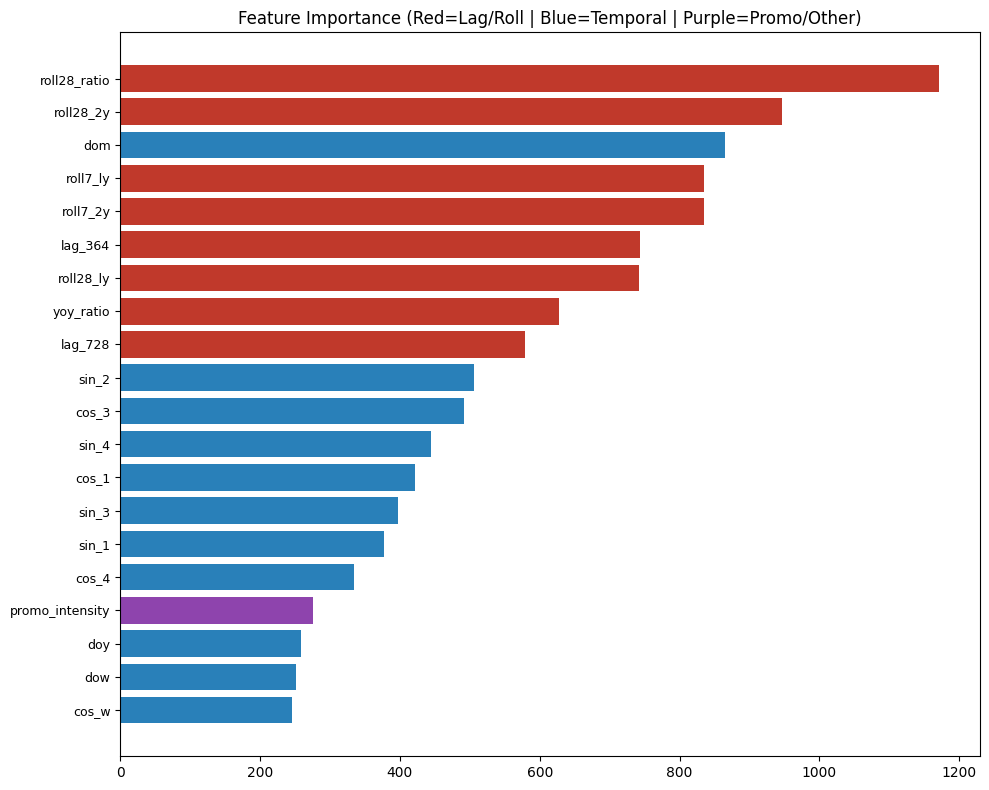

In [12]:
# ── Feature Importance
fi = (pd.DataFrame({'feature': FEAT_COLS, 'importance': m_full.feature_importances_})
      .sort_values('importance', ascending=False))
print("Top 20 Features:")
display(fi.head(20))

fig, ax = plt.subplots(figsize=(10, 8))
fi_top = fi.head(20)
colors = ['#C0392B' if any(x in f for x in ['lag','roll','yoy','cr_']) else
          '#2980B9' if any(x in f for x in ['sin','cos','month','dom','dow','doy','quarter']) else
          '#8E44AD' for f in fi_top['feature']]
ax.barh(range(len(fi_top)), fi_top['importance'].values[::-1], color=colors[::-1])
ax.set_yticks(range(len(fi_top)))
ax.set_yticklabels(fi_top['feature'].values[::-1], fontsize=9)
ax.set_title('Feature Importance (Red=Lag/Roll | Blue=Temporal | Purple=Promo/Other)')
plt.tight_layout()
plt.show()

In [13]:
# ── Test prediction
print(f"Test predictions: mean={vp_final_test.mean():,.0f}  std={vp_final_test.std():,.0f}  max={vp_final_test.max():,.0f}")
print(f"Sample baseline : mean={df_sample_submission['Revenue'].mean():,.0f}  std={df_sample_submission['Revenue'].std():,.0f}  max={df_sample_submission['Revenue'].max():,.0f}")

Test predictions: mean=3,413,302  std=1,571,537  max=10,011,640
Sample baseline : mean=3,249,795  std=1,581,698  max=9,283,417


⏳ Đang tính toán SHAP values (Có thể mất vài phút tùy lượng data)...
✅ Đã tính toán xong! Bắt đầu vẽ biểu đồ...


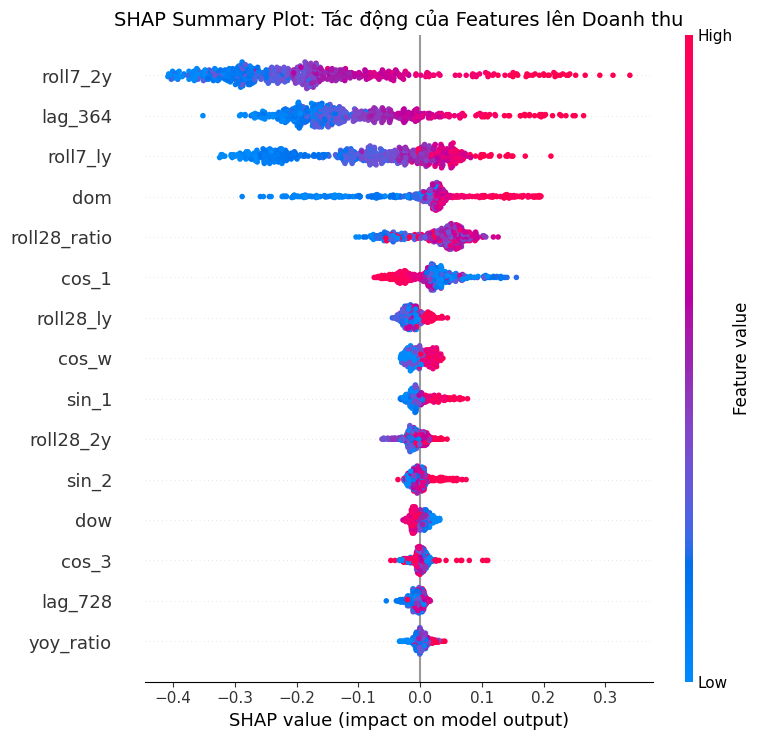


🔍 GIẢI THÍCH CHI TIẾT NGÀY CÓ DOANH THU ĐỈNH: 2022-03-30


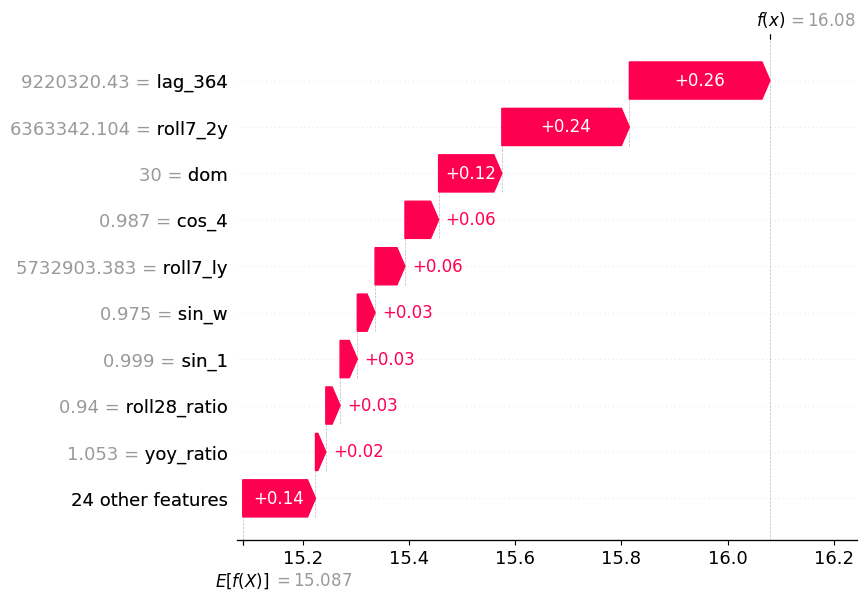

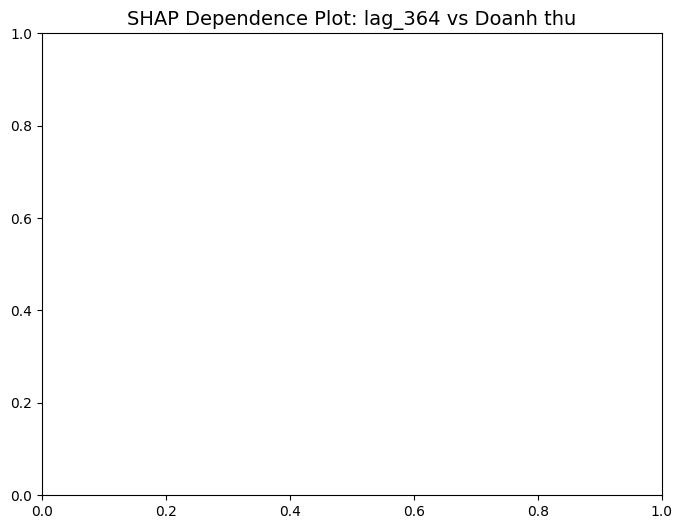

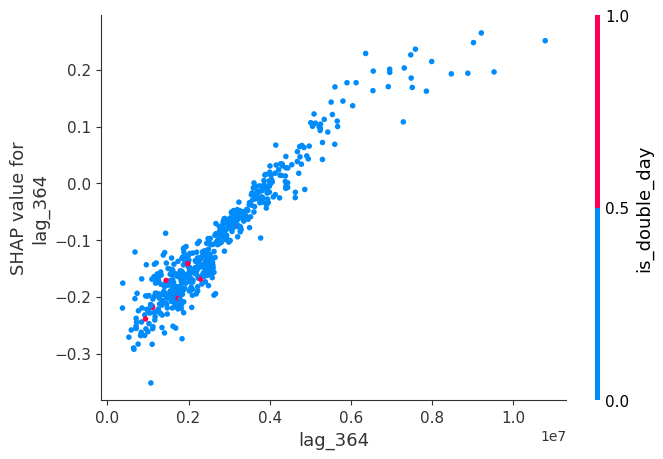

In [14]:
import shap
import matplotlib.pyplot as plt

# Khởi tạo Javascript để vẽ biểu đồ tương tác (nếu dùng Jupyter)
shap.initjs()

print("⏳ Đang tính toán SHAP values (Có thể mất vài phút tùy lượng data)...")
# 1. Khởi tạo TreeExplainer cho mô hình LightGBM
explainer = shap.TreeExplainer(m_full)

# Lấy tập Validation (hoặc 1 năm dữ liệu gần nhất) để giải thích
# Không nên lấy toàn bộ tập Train vì tính toán sẽ rất lâu
X_explain = X_va.copy() 

# 2. Tính toán ma trận SHAP
shap_values = explainer.shap_values(X_explain)

print("✅ Đã tính toán xong! Bắt đầu vẽ biểu đồ...")

# ==============================================================================
# BIỂU ĐỒ 1: TẦM QUAN TRỌNG VÀ TÁC ĐỘNG TỔNG QUAN (SUMMARY PLOT)
# ==============================================================================
plt.figure(figsize=(10, 8))
plt.title("SHAP Summary Plot: Tác động của Features lên Doanh thu", fontsize=14)
shap.summary_plot(shap_values, X_explain, max_display=15)
# Lưu ý: Lệnh summary_plot tự động show, không cần plt.show()

# ==============================================================================
# BIỂU ĐỒ 2: GIẢI THÍCH MỘT NGÀY CỤ THỂ (WATERFALL PLOT)
# ==============================================================================
# Chọn một ngày có doanh thu cực cao trong tập Val (Ví dụ: Đỉnh Sale hoặc cận Tết)
# Tìm index của ngày có doanh thu dự báo cao nhất
max_pred_idx = np.argmax(m_full.predict(X_explain))
max_date = df.loc[val_mask, 'Date'].iloc[max_pred_idx]

print(f"\n🔍 GIẢI THÍCH CHI TIẾT NGÀY CÓ DOANH THU ĐỈNH: {max_date.date()}")

plt.figure(figsize=(10, 6))
# Lấy ra dòng dữ liệu và SHAP value của ngày đó
shap_values_single = explainer(X_explain.iloc[[max_pred_idx]])
shap.plots.waterfall(shap_values_single[0], max_display=10)

# ==============================================================================
# BIỂU ĐỒ 3: PHÂN TÍCH CHUYÊN SÂU 1 BIẾN (DEPENDENCE PLOT)
# ==============================================================================
# Xem xét biến lag_364 tác động thế nào khi kết hợp với biến sự kiện (is_double_day)
plt.figure(figsize=(8, 6))
plt.title("SHAP Dependence Plot: lag_364 vs Doanh thu", fontsize=14)
shap.dependence_plot("lag_364", shap_values, X_explain, interaction_index="is_double_day")